Demand Forecasting Project

1. Loading Dataset

In [6]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

print(df.head())
print(df.info())
print(df.describe())

         date store_id item_id  sales  price  promo  weekday  month
0  2019-01-01  store_1  item_1     41  21.30      0        1      1
1  2019-01-02  store_1  item_1     53  21.30      0        2      1
2  2019-01-03  store_1  item_1     39  21.30      0        3      1
3  2019-01-04  store_1  item_1     35  21.30      0        4      1
4  2019-01-05  store_1  item_1     51  17.04      1        5      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB
None
              sales         price         promo       weekday         month
count  4.565000e+06  4.565000e+06  4.565000e+06  4.565000e+06  4.565000e+06
mean   2.926466e+01  5.399323

2. Data Quality Check

In [7]:
#check missing values
df.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [8]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
#Convert date column
#Ml models cannot understand raw text dates
df['date'] = pd.to_datetime(df['date'])

3. Exploratory Data Analysis(EDA)

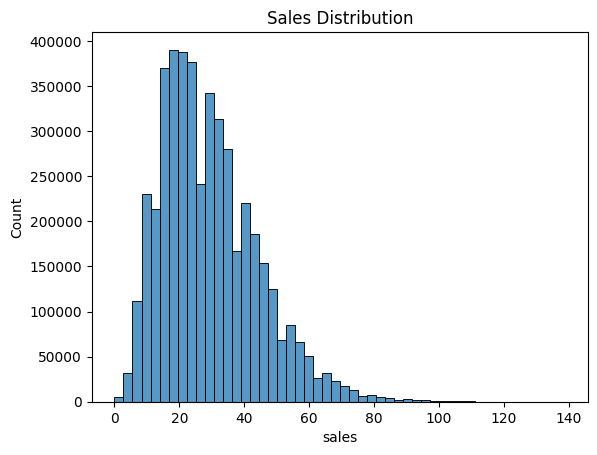

In [10]:
#sales distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['sales'], bins=50)
plt.title("Sales Distribution")
plt.show()

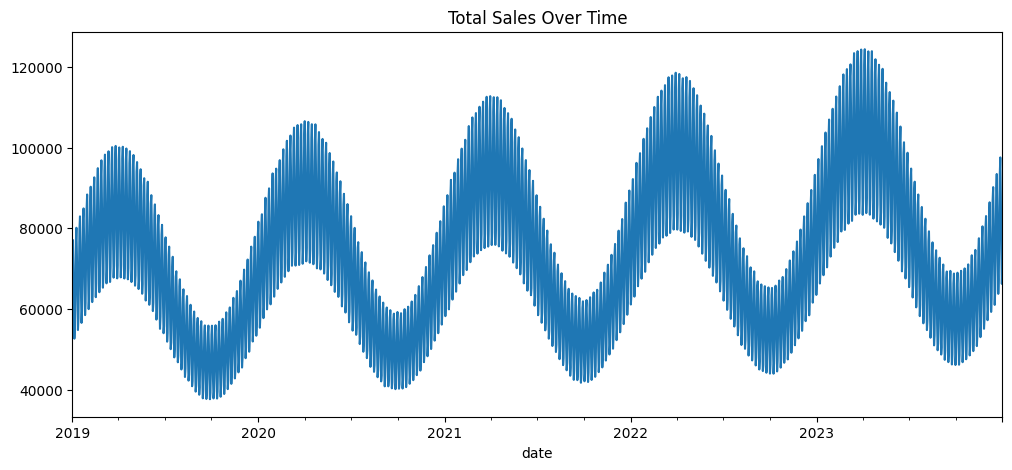

In [11]:
#sales trend overtime
daily_sales = df.groupby('date')['sales'].sum()

daily_sales.plot(figsize=(12,5))
plt.title("Total Sales Over Time")
plt.show()

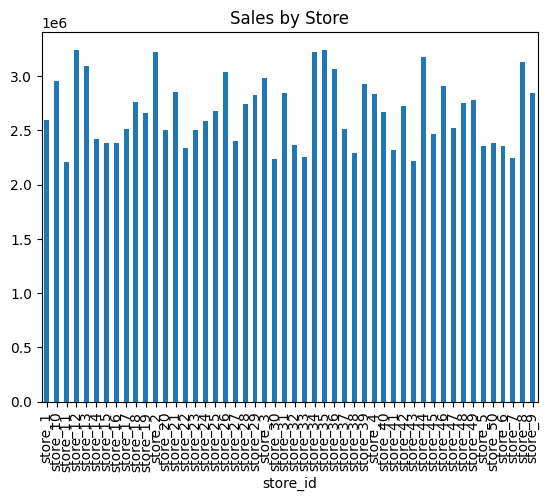

In [12]:
#store performance
store_sales = df.groupby('store_id')['sales'].sum()

store_sales.plot(kind='bar')
plt.title("Sales by Store")
plt.show()

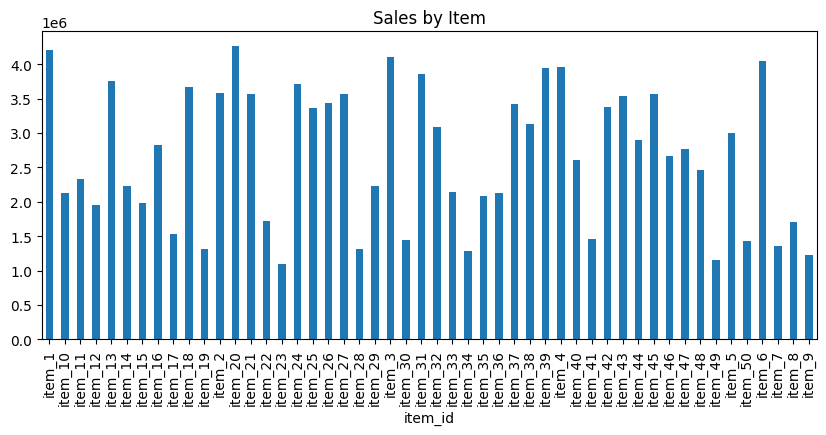

In [13]:
#Item demand
item_sales = df.groupby('item_id')['sales'].sum()

item_sales.plot(kind='bar', figsize=(10,4))
plt.title("Sales by Item")
plt.show()

4. Feature Engineering

In [14]:
#sort the dataset by time
df = df.sort_values(["store_id", "item_id", "date"])

In [15]:
#these lag features represent previous sales values
df["lag_7"] = df.groupby(["store_id", "item_id"])["sales"].shift(7)
df["lag_14"] = df.groupby(["store_id", "item_id"])["sales"].shift(14)
df["lag_30"] = df.groupby(["store_id", "item_id"])["sales"].shift(30)

In [16]:
#Rolling Mean Features
#represent recent trend of demand
df["rolling_mean_7"] = (
    df.groupby(["store_id", "item_id"])["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

df["rolling_mean_30"] = (
    df.groupby(["store_id", "item_id"])["sales"]
    .shift(1)
    .rolling(30)
    .mean()
)

In [17]:
#drop missing values
df = df.dropna()

In [18]:
#remove date column
df = df.drop("date", axis=1)

5. Feature Selection

6. Train Test Split

In [19]:
#convert categorical columns to numeric 
#Label encoding using pandas
df["store_id"] = df["store_id"].astype("category").cat.codes
df["item_id"] = df["item_id"].astype("category").cat.codes

In [20]:
#sampling
sample_df = df.sample(100000, random_state=42)
 
#Feature split 
X = sample_df.drop("sales", axis=1)
y = sample_df["sales"]

#Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

7. Linear Regression

In [21]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [22]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Linear Regression
MAE: 3.6164932122698823
RMSE: 4.6826043267757225


8. Random Forest

In [23]:
#Train Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [24]:
#evaluation
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
MAE: 2.7201614999999997
RMSE: 3.4236936158190328


9. XGBoost

In [25]:
#Train XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    tree_method="hist"
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [26]:
#evaluation
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("XGBoost")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

XGBoost
MAE: 2.5834696292877197
RMSE: 3.2289981100739036


10. Result Comparison

In [27]:
print("Linear Regression MAE:", mae_lr)
print("Random Forest MAE:", mae_rf)
print("XGBoost MAE:", mae_xgb)

Linear Regression MAE: 3.6164932122698823
Random Forest MAE: 2.7201614999999997
XGBoost MAE: 2.5834696292877197


11. Hyperparameter Tuning for Random Forest

In [28]:
import pandas as pd

# take a smaller sample
sample_df = df.sample(n=100000, random_state=42)

print(sample_df.shape)

(100000, 12)


In [29]:
#split features and target
X = sample_df.drop("sales", axis=1)
y = sample_df["sales"]

In [30]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
#convert datatypes to reduce RAM
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [32]:
#Random Forest Hyperparameter Tuning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=4,
    cv=2,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    random_state=42
)

search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 15], 'min_samples_split': [2, 5], 'n_estimators': [100, 150]}"
,n_iter,4
,scoring,'neg_mean_absolute_error'
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [33]:
#Training the optimized model
best_rf = search.best_estimator_
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.713324072672425
RMSE: 3.415080571544453


12. Hyperparameter Tuning for XGBoost

In [34]:
#import and define the model
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

In [35]:
#search space
param_grid = {
    "n_estimators": [150, 200],
    "max_depth": [6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [36]:
#randomized search
search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=5,
    cv=2,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    random_state=42
)

search_xgb.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05, 0.1], 'max_depth': [6, 8], 'n_estimators': [150, 200], ...}"
,n_iter,5
,scoring,'neg_mean_absolute_error'
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [37]:
best_xgb = search_xgb.best_estimator_
pred_xgb = best_xgb.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("Tuned XGBoost")
print("MAE:", mae)
print("RMSE:", rmse)

Tuned XGBoost
MAE: 2.5899863243103027
RMSE: 3.237865094546621


In [38]:
import joblib

joblib.dump(best_xgb, "sales_forecast_model.pkl")

['sales_forecast_model.pkl']